# Non-electricity fuel demand calibration for Morocco (2022 baseline)

Diagnoses and (optionally) corrects per-(sector, fuel) demand for the 9 non-electricity fuels in SISEPUEDE: `biomass`, `coal`, `coke`, `diesel`, `gasoline`, `hydrocarbon_gas_liquids` (LPG), `kerosene`, `natural_gas`, `oil`.

For each fuel the table identifies the **dominant sector** (where it's anchored) and compares the model's output against a reasonable target derived from Morocco's national energy balance and IEA country profile (see `NON_ELEC_TARGETS_PJ_2022`).

**Default behavior is diagnostic-only.** To apply corrections, fill `FRAC_OVERRIDES` with `{(industry_or_scoe_cat, fuel): new_fraction}` pairs; the notebook will renormalize the complementary fractions so each sector's fuel shares still sum to 1.

Starts from the latest INEN+SCOE-electricity-calibrated base (default: `sisepuede_raw_inputmorocco.csv`).

In [22]:
# ============================================================
# Parameters
# ============================================================

# Base CSV (latest electricity-calibrated file from recalibrate_inen_scoe notebook)
BASE_INPUT_CSV = "../../input_data/sisepuede_raw_input_morocco.csv"

# Output CSV
OUT_INPUT_CSV  = "../../input_data/sisepuede_raw_input_morocco_fuels.csv"

CALIB_YEAR = 2022
BASE_YEAR = 2015
TERMINAL_YEAR = 2050
REGION = "morocco"
REL_TOLERANCE = 0.10   # 10% for per-(sector,fuel) cell (looser than electricity since fuels are smaller)

# ============================================================
# Target totals per (fuel, sector_aggregate) for CALIB_YEAR (PJ)
# ============================================================
# Sources:
#   - Morocco IEA country profile 2022 (https://www.iea.org/countries/morocco)
#   - HCP Balance Énergétique Nationale 2022
#   - SNBC vol 2 / LT-LEDS Morocco (2030 mix interpolated back)
#   - calibration_log.md NIR-verified entries
#
# Sector aggregates:
#   INEN = all industrial energy (12 virgin + 7 recycled subsectors + agri + other_mfg)
#   SCOE = residential + commercial_municipal + other_se
#   TRNS = all transport modes
#
# These are STARTING ESTIMATES; refine as better data becomes available.
NON_ELEC_TARGETS_PJ_2022 = {
    ("biomass",                 "INEN"): 12.0,   # Agri-food residues (olive pomace, sugar bagasse)
    ("biomass",                 "SCOE"): 55.0,   # Rural residential firewood (~1.3 Mtoe)
    ("coal",                    "INEN"): 12.0,   # Cement industry (Lafarge/Holcim coal kilns)
    ("coal",                    "SCOE"):  0.0,
    ("coke",                    "INEN"):  5.0,   # Sonasid steel (small Moroccan steel industry)
    ("diesel",                  "INEN"): 35.0,   # Heavy machinery, mining, agriculture
    ("diesel",                  "TRNS"):195.0,   # Road freight + buses + agricultural vehicles
    ("gasoline",                "INEN"):  0.0,
    ("gasoline",                "TRNS"): 85.0,   # Light vehicles (~85 PJ already matches model)
    ("hydrocarbon_gas_liquids", "INEN"):  2.0,
    ("hydrocarbon_gas_liquids", "SCOE"): 50.0,   # Residential cooking LPG (~1.2 Mtoe)
    ("hydrocarbon_gas_liquids", "TRNS"):  3.0,   # LPG vehicles (small)
    ("kerosene",                "INEN"):  1.0,
    ("kerosene",                "SCOE"):  2.0,
    ("kerosene",                "TRNS"): 32.0,   # Aviation jet fuel
    ("natural_gas",             "INEN"): 30.0,   # OCP ammonia + industrial heat (~0.8 Mtoe to INEN)
    ("natural_gas",             "SCOE"):  4.0,   # Limited residential NG distribution
    ("oil",                     "INEN"): 15.0,   # Heavy fuel oil for industry
    ("oil",                     "SCOE"):  0.0,
}

# ============================================================
# Stage B overrides (optional, empty by default)
# ============================================================
# Map: (industry_or_scoe_cat, fuel_output_name) -> new_fraction (0.0 to 1.0).
# Multiple fuels per subcategory are processed jointly; non-overridden fuels for that
# subcategory are renormalized proportionally to fill (1 - sum_of_overrides).
#
# INEN industries:  cement, chemicals, electronics, glass, lime_and_carbonite, metals,
#                   mining, paper, plastic, rubber_and_leather, textiles, wood,
#                   plus 7 recycled_* twins, agriculture_and_livestock, other_product_manufacturing
# SCOE categories:  residential, commercial_municipal, other_se
#
# Fuel names (output side - notebook auto-translates biomass -> solid_biomass for input col):
#   biomass, coal, coke, diesel, electricity, furnace_gas, gasoline,
#   hydrocarbon_gas_liquids (LPG), hydrogen, kerosene, natural_gas, oil, solar
#
# ============================================================================
# Morocco 2022 baseline fuel mix per subcategory
# ============================================================================
# Sources:
#   - IEA Morocco country profile 2022 (sectoral fuel allocation)
#   - HCP Maroc, Balance Énergétique Nationale 2022
#   - SNBC vol 2 / LT-LEDS Morocco 2024
#   - OCP annual report 2022 (chemicals/fertilizer fuel mix)
#   - Lafarge Morocco sustainability report (cement kiln mix)
#   - Sonasid + Maghreb Steel + Aluminium du Maroc (EAF electric-dominant)
#   - Cellulose du Maroc (paper, black liquor + electricity)
#   - ONEE statistics (residential electrification + LPG subsidy data)
#
# Each subcategory mix sums to ~1.00; the notebook renormalizes any small slack
# across the non-overridden fuels (kerosene/hydrogen/furnace_gas/gasoline mostly).

FRAC_OVERRIDES = {
    # ------------------------------------------------------------
    # SCOE (heat fractions only; appliances are 100% electricity by definition)
    # ------------------------------------------------------------
    # Residential heat (cooking + water heating + space heating)
    # LPG dominant due to butane bottle subsidy, biomass=rural firewood (declining),
    # electricity rising (heat pumps + electric water heaters)
    ("residential", "hydrocarbon_gas_liquids"): 0.30,
    ("residential", "biomass"):                  0.20,
    ("residential", "electricity"):              0.40,
    ("residential", "natural_gas"):              0.05,
    ("residential", "kerosene"):                 0.03,

    # Commercial & municipal heat (offices, public buildings, hospitals)
    # NG higher share (urban Casablanca/Rabat gas distribution), some LPG
    ("commercial_municipal", "hydrocarbon_gas_liquids"): 0.15,
    ("commercial_municipal", "natural_gas"):              0.40,
    ("commercial_municipal", "electricity"):              0.35,
    ("commercial_municipal", "diesel"):                   0.07,
    ("commercial_municipal", "biomass"):                  0.03,

    # Other services (non-classified, hotels, restaurants)
    # Diesel for backup generators + heating; mix of fuels
    ("other_se", "hydrocarbon_gas_liquids"): 0.10,
    ("other_se", "natural_gas"):              0.20,
    ("other_se", "electricity"):              0.40,
    ("other_se", "diesel"):                   0.20,
    ("other_se", "biomass"):                  0.10,

    # ------------------------------------------------------------
    # INEN — high-temperature industries
    # ------------------------------------------------------------
    # Cement (Lafarge, Holcim, Ciments du Maroc - dominant Moroccan industrial CO2)
    # Coal+petcoke kilns dominant; biomass alt fuels growing; small NG/oil/electricity
    ("cement", "coal"):          0.55,
    ("cement", "coke"):          0.20,
    ("cement", "biomass"):       0.08,
    ("cement", "electricity"):   0.10,
    ("cement", "oil"):           0.04,
    ("cement", "natural_gas"):   0.03,

    # Chemicals (OCP fertilizers - dominant, primarily ammonia + phosphoric acid)
    # NG very dominant for ammonia synthesis; electricity for processing
    ("chemicals", "natural_gas"):  0.55,
    ("chemicals", "electricity"):  0.25,
    ("chemicals", "oil"):          0.10,
    ("chemicals", "coal"):         0.05,
    ("chemicals", "biomass"):      0.03,
    ("chemicals", "coke"):         0.02,

    # Metals (Sonasid + Maghreb Steel = EAF dominant; Aluminium du Maroc = electric smelting)
    # Morocco has ~no integrated steelworks => very low coke; mostly EAF + smelting
    ("metals", "electricity"):  0.70,
    ("metals", "natural_gas"):  0.10,
    ("metals", "oil"):          0.10,
    ("metals", "coke"):         0.05,
    ("metals", "biomass"):      0.05,

    # Glass (Sevam, small Moroccan glass industry)
    # NG dominant for melting tanks; electricity for forming
    ("glass", "natural_gas"):  0.55,
    ("glass", "electricity"):  0.30,
    ("glass", "oil"):          0.10,
    ("glass", "coal"):         0.05,

    # Lime and carbonite (small kilns, similar to cement but smaller scale)
    ("lime_and_carbonite", "coal"):         0.40,
    ("lime_and_carbonite", "natural_gas"):  0.25,
    ("lime_and_carbonite", "oil"):          0.15,
    ("lime_and_carbonite", "electricity"):  0.20,

    # ------------------------------------------------------------
    # INEN — light industries
    # ------------------------------------------------------------
    # Mining (OCP phosphate rock extraction - dominant; plus minor mining)
    # Diesel haul trucks dominant; electricity for processing/crushing
    ("mining", "diesel"):       0.60,
    ("mining", "electricity"):  0.35,
    ("mining", "oil"):          0.03,
    ("mining", "hydrocarbon_gas_liquids"): 0.02,

    # Paper (Cellulose du Maroc + small mills)
    # Black liquor / wood waste biomass + electricity; some NG/oil for steam
    ("paper", "biomass"):       0.30,
    ("paper", "electricity"):   0.40,
    ("paper", "natural_gas"):   0.15,
    ("paper", "oil"):           0.15,

    # Plastic (forming + extrusion - electric dominated)
    ("plastic", "electricity"):   0.50,
    ("plastic", "natural_gas"):   0.30,
    ("plastic", "oil"):           0.20,

    # Textiles (Tangier/Casablanca textile zone)
    # Mixed electricity (machinery) + thermal (dyeing, finishing - NG/oil)
    ("textiles", "electricity"):   0.40,
    ("textiles", "natural_gas"):   0.20,
    ("textiles", "oil"):           0.20,
    ("textiles", "biomass"):       0.20,

    # Wood products (sawmills, panel production)
    # Self-supply biomass + electricity dominant
    ("wood", "biomass"):       0.40,
    ("wood", "electricity"):   0.40,
    ("wood", "oil"):           0.15,
    ("wood", "diesel"):        0.05,

    # Rubber and leather
    ("rubber_and_leather", "electricity"):   0.40,
    ("rubber_and_leather", "natural_gas"):   0.25,
    ("rubber_and_leather", "oil"):           0.20,
    ("rubber_and_leather", "biomass"):       0.15,

    # Electronics (small industry, assembly mostly)
    ("electronics", "electricity"):   0.85,
    ("electronics", "natural_gas"):   0.10,
    ("electronics", "oil"):           0.05,

    # ------------------------------------------------------------
    # INEN — other catch-all categories
    # ------------------------------------------------------------
    # Other product manufacturing (machinery, automotive Renault/Stellantis assembly, etc.)
    ("other_product_manufacturing", "electricity"):   0.50,
    ("other_product_manufacturing", "natural_gas"):   0.20,
    ("other_product_manufacturing", "diesel"):        0.15,
    ("other_product_manufacturing", "oil"):           0.10,
    ("other_product_manufacturing", "biomass"):       0.05,

    # Agriculture and livestock (tractors + pumping + dairy chillers)
    ("agriculture_and_livestock", "diesel"):                   0.65,
    ("agriculture_and_livestock", "electricity"):              0.25,
    ("agriculture_and_livestock", "hydrocarbon_gas_liquids"):  0.05,
    ("agriculture_and_livestock", "biomass"):                  0.05,

    # NOTE: recycled_* subcategories are NOT overridden — their production is ~zero
    # in current Morocco model so they contribute negligibly to the totals.
}


In [23]:
import os, sys, pathlib, warnings, logging
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

HERE = pathlib.Path(os.getcwd())
sys.path.insert(0, str(HERE.parent))
from utils.logger_utils import setup_clean_logger, mute_external_loggers
logger = setup_clean_logger("recalib_fuels", logging.INFO)
mute_external_loggers(["sisepuede"])

PJ_TO_GWH = 1000.0 / 3.6
GWH_TO_PJ = 3.6 / 1000.0

NON_ELEC_FUELS = [
    "biomass", "coal", "coke", "diesel", "gasoline",
    "hydrocarbon_gas_liquids", "kerosene", "natural_gas", "oil",
]
SECTORS = ["INEN", "SCOE", "TRNS", "CCSQ"]


## 1. Helpers

In [24]:
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
from ssp_transformations_handler.GeneralUtils import GeneralUtils

_EX = sxl.SISEPUEDEExamples()


def run_energy_only(csv_path: str, y0: int = BASE_YEAR, y1: int = 2050) -> pd.DataFrame:
    df_raw = pd.read_csv(csv_path)
    fs = sfs.SISEPUEDEFileStructure(initialize_directories=False)
    key_tp = fs.model_attributes.dim_time_period
    key_year = fs.model_attributes.field_dim_year
    years = np.arange(y0, y1 + 1).astype(int)
    att_tp = att.AttributeTable(
        pd.DataFrame({key_tp: range(len(years)), key_year: years}), key_tp,
    )
    fs.model_attributes.update_dimensional_attribute_table(att_tp)
    models = sm.SISEPUEDEModels(
        fs.model_attributes, allow_electricity_run=False,
        fp_julia=fs.dir_jl, fp_nemomod_reference_files=fs.dir_ref_nemo,
        initialize_julia=False,
    )
    df_ex = _EX("input_data_frame")
    df = GeneralUtils().add_missing_cols(df_ex, df_raw.copy())
    df["region"] = REGION
    df = df[df["year"] <= y1]
    df_out = models.project(df, include_electricity_in_energy=False)
    df_out["year"] = df_out["time_period"].apply(lambda t: y0 + int(t))
    return df_out


def demand_by_fuel_sector(df_out: pd.DataFrame, year: int) -> pd.DataFrame:
    """Return per-(sector aggregate, fuel) demand in PJ at given year.
    
    Reads `energy_demand_enfu_subsector_total_pj_<sector>_fuel_<fuel>` columns.
    Returns DataFrame indexed by fuel with columns INEN, SCOE, TRNS, CCSQ, TOTAL.
    """
    row = df_out[df_out["year"] == year].iloc[0]
    data = {sec: {} for sec in SECTORS}
    fuels_seen = set()
    for sec in SECTORS:
        prefix = f"energy_demand_enfu_subsector_total_pj_{sec.lower()}_fuel_"
        for c in df_out.columns:
            if not c.startswith(prefix):
                continue
            fuel = c.replace(prefix, "")
            data[sec][fuel] = float(row[c])
            fuels_seen.add(fuel)
    rows = []
    for fuel in sorted(fuels_seen):
        row_d = {"fuel": fuel}
        for sec in SECTORS:
            row_d[sec] = data[sec].get(fuel, 0.0)
        row_d["TOTAL"] = sum(row_d[s] for s in SECTORS)
        rows.append(row_d)
    return pd.DataFrame(rows).set_index("fuel")


## 2. Stage A — Diagnose per-(sector, fuel) demand vs targets

Runs the energy model on the base CSV and compares each (sector, fuel) cell against the reasonable target in `NON_ELEC_TARGETS_PJ_2022`. Flags cells outside ±10% as **MISS**.

In [25]:
print(f"Running EnergyConsumption only on {BASE_INPUT_CSV} ...")
df_out_base = run_energy_only(BASE_INPUT_CSV)
fuel_table = demand_by_fuel_sector(df_out_base, CALIB_YEAR)

# Build the diagnostic table with targets and gaps
print(f"\n" + "=" * 95)
print(f"Non-electricity fuel demand by sector at {CALIB_YEAR} (PJ)")
print("=" * 95)
print(f"{'fuel':<28} {'INEN_now':>9} {'INEN_tgt':>9} {'gap':>8} | "
      f"{'SCOE_now':>9} {'SCOE_tgt':>9} {'gap':>8} | "
      f"{'TRNS_now':>9} {'TRNS_tgt':>9} {'gap':>8}")
print("-" * 95)

diagnostic = []
for fuel in NON_ELEC_FUELS:
    if fuel not in fuel_table.index:
        continue
    row = fuel_table.loc[fuel]
    line_parts = [f"{fuel:<28}"]
    for sec in ["INEN", "SCOE", "TRNS"]:
        now = float(row[sec])
        tgt = NON_ELEC_TARGETS_PJ_2022.get((fuel, sec), None)
        if tgt is None:
            line_parts.append(f"{now:>9.2f} {'-':>9} {'-':>8}")
        else:
            gap = now - tgt
            mark = ""
            if tgt > 0.01:
                if abs(gap)/tgt > REL_TOLERANCE:
                    mark = " *"
            elif abs(now) > 0.5:
                mark = " *"
            line_parts.append(f"{now:>9.2f} {tgt:>9.2f} {gap:>+7.2f}{mark}")
            diagnostic.append({"fuel": fuel, "sector": sec, "now": now, "tgt": tgt, "gap": gap})
    print(" | ".join([line_parts[0]] + line_parts[1:]))

diag_df = pd.DataFrame(diagnostic)
print(f"\n* = outside ±{REL_TOLERANCE*100:.0f}% tolerance (or non-trivial when target=0)")
print(f"\nMisses to attend ({len(diag_df[abs(diag_df['gap']) > REL_TOLERANCE * diag_df['tgt'].clip(lower=0.01)])}):")
sub = diag_df[abs(diag_df["gap"]) > REL_TOLERANCE * diag_df["tgt"].clip(lower=0.01)].copy()
sub["pct"] = sub["gap"] / sub["tgt"].replace(0, np.nan) * 100
print(sub.sort_values("gap", key=abs, ascending=False).to_string(index=False,
      float_format=lambda x: f"{x:+.2f}"))


Running EnergyConsumption only on ../../input_data/sisepuede_raw_input_morocco.csv ...

Non-electricity fuel demand by sector at 2022 (PJ)
fuel                          INEN_now  INEN_tgt      gap |  SCOE_now  SCOE_tgt      gap |  TRNS_now  TRNS_tgt      gap
-----------------------------------------------------------------------------------------------
biomass                      |     13.64     12.00   +1.64 * |     94.52     55.00  +39.52 * |      0.00         -        -
coal                         |      3.48     12.00   -8.52 * |      0.00      0.00   +0.00 |      0.00         -        -
coke                         |     22.10      5.00  +17.10 * |      0.00         -        - |      0.00         -        -
diesel                       |     47.20     35.00  +12.20 * |      0.00         -        - |    163.41    195.00  -31.59 *
gasoline                     |      6.50      0.00   +6.50 * |      0.00         -        - |     79.70     85.00   -5.30
hydrocarbon_gas_liquids      |

## 3. Stage B — Optional fraction overrides + renormalization

For each `(sector_subcategory, fuel) -> new_fraction` entry in `FRAC_OVERRIDES`, this cell:
1. Locates the `frac_inen_energy_<industry>_<fuel>` or `frac_scoe_energy_<cat>_<fuel>` column
2. Sets the fraction at `time_period == CALIB_YEAR - BASE_YEAR` to the new value
3. Renormalizes the remaining fuel fractions for that (sector, year) so they sum to (1 − new_fraction)
4. Holds the new fractions flat from CALIB_YEAR to TERMINAL_YEAR

If `FRAC_OVERRIDES` is empty, this cell is a no-op and the output CSV equals the base.

In [26]:
df_in = pd.read_csv(BASE_INPUT_CSV)

# Canonical fuel suffixes per sector (from inspecting the input CSV directly)
INEN_FUEL_SUFFIXES = [
    "coal", "coke", "diesel", "electricity", "furnace_gas", "gasoline",
    "hydrocarbon_gas_liquids", "hydrogen", "kerosene", "natural_gas",
    "oil", "solar", "solid_biomass",
]
SCOE_FUEL_SUFFIXES = [
    "coal", "diesel", "electricity", "gasoline", "hydrocarbon_gas_liquids",
    "hydrogen", "kerosene", "natural_gas", "solid_biomass",
]

# Translation: output demand fuel name -> input frac fuel name
# (biomass in outputs corresponds to solid_biomass in frac inputs)
OUTPUT_TO_INPUT_FUEL = {"biomass": "solid_biomass"}
def input_fuel(fuel_out: str) -> str:
    return OUTPUT_TO_INPUT_FUEL.get(fuel_out, fuel_out)

# Discover subcategories by stripping known fuel suffixes from frac column names
def _extract_subcats(df_cols, prefix, fuel_suffixes):
    out = set()
    for c in df_cols:
        if not c.startswith(prefix):
            continue
        tail = c[len(prefix):]
        for fuel in fuel_suffixes:
            if tail.endswith("_" + fuel):
                out.add(tail[: -(len(fuel) + 1)])
                break
    return sorted(out)

INEN_SUBCATS = _extract_subcats(df_in.columns, "frac_inen_energy_", INEN_FUEL_SUFFIXES)
SCOE_SUBCATS = _extract_subcats(df_in.columns, "frac_scoe_heat_energy_", SCOE_FUEL_SUFFIXES)


def find_frac_cols(subcat: str, sector_hint: str = None):
    """Return (sector_label, list_of_fuel_frac_cols) for subcategory."""
    if sector_hint == "INEN" or subcat in INEN_SUBCATS:
        prefix = f"frac_inen_energy_{subcat}_"
        cols = [f"{prefix}{f}" for f in INEN_FUEL_SUFFIXES if f"{prefix}{f}" in df_in.columns]
        return "INEN", cols
    if sector_hint == "SCOE" or subcat in SCOE_SUBCATS:
        prefix = f"frac_scoe_heat_energy_{subcat}_"
        cols = [f"{prefix}{f}" for f in SCOE_FUEL_SUFFIXES if f"{prefix}{f}" in df_in.columns]
        return "SCOE", cols
    return None, []

print(f"INEN subcategories detected ({len(INEN_SUBCATS)}): {INEN_SUBCATS[:8]}...")
print(f"SCOE subcategories detected ({len(SCOE_SUBCATS)}): {SCOE_SUBCATS}")

if not FRAC_OVERRIDES:
    print(f"\nFRAC_OVERRIDES is empty -> Stage B is no-op. Writing base unchanged to {OUT_INPUT_CSV}")
    df_in.to_csv(OUT_INPUT_CSV, index=False)
else:
    tp_calib = CALIB_YEAR - BASE_YEAR
    tp_terminal = TERMINAL_YEAR - BASE_YEAR
    
    # Group overrides by subcategory so multiple fuel overrides for the same subcat
    # are applied jointly (with combined renormalization of non-overridden fuels).
    from collections import defaultdict
    by_subcat = defaultdict(dict)  # subcat -> {fuel_in_csv: new_frac}
    for (subcat, fuel_out), new_frac in FRAC_OVERRIDES.items():
        by_subcat[subcat][input_fuel(fuel_out)] = float(new_frac)
    
    print(f"\nApplying {len(FRAC_OVERRIDES)} override(s) across {len(by_subcat)} subcategory group(s)")
    print(f"  Window: tp {tp_calib} ({CALIB_YEAR}) to tp {tp_terminal} ({TERMINAL_YEAR}) with hold")
    
    for subcat, fuel_to_frac in by_subcat.items():
        sector, all_frac_cols = find_frac_cols(subcat)
        if not all_frac_cols:
            print(f"  SKIP {subcat!r}: no frac columns found")
            continue
        
        # Resolve which columns are overridden vs free for renormalization
        if sector == "SCOE":
            col_prefix = f"frac_scoe_heat_energy_{subcat}_"
        else:
            col_prefix = f"frac_inen_energy_{subcat}_"
        overridden_cols = {}  # col_name -> new_value
        for fuel_in, frac in fuel_to_frac.items():
            tcol = f"{col_prefix}{fuel_in}"
            if tcol not in all_frac_cols:
                print(f"  SKIP ({subcat}, {fuel_in}): column {tcol!r} not in CSV")
                continue
            overridden_cols[tcol] = frac
        if not overridden_cols:
            continue
        s_override = sum(overridden_cols.values())
        if s_override > 1.0 + 1e-6:
            print(f"  ERROR {subcat!r}: overrides sum to {s_override:.4f} > 1. Skipping.")
            continue
        remaining = max(0.0, 1.0 - s_override)
        free_cols = [c for c in all_frac_cols if c not in overridden_cols]
        
        # Apply for each time period in the hold window
        for tp in range(tp_calib, tp_terminal + 1):
            mask = df_in["time_period"] == tp
            free_sum_old = float(df_in.loc[mask, free_cols].sum(axis=1).iloc[0])
            # Set overridden columns
            for c, v in overridden_cols.items():
                df_in.loc[mask, c] = v
            # Renormalize free columns to fill remaining
            if free_sum_old > 1e-9 and free_cols:
                scale = remaining / free_sum_old
                for c in free_cols:
                    df_in.loc[mask, c] = df_in.loc[mask, c] * scale
            elif free_cols:
                # No room or all free were zero -> distribute evenly
                for c in free_cols:
                    df_in.loc[mask, c] = remaining / len(free_cols)
        
        # Log line summarising the group
        ov_summary = ", ".join(f"{c.replace(col_prefix,'')}={v:.3f}" for c,v in overridden_cols.items())
        print(f"  {subcat:<28} [{sector}]: overrides sum={s_override:.4f}, free={len(free_cols)} cols share {remaining:.4f} | {ov_summary}")
    
    df_in.to_csv(OUT_INPUT_CSV, index=False)
    print(f"\nWrote: {OUT_INPUT_CSV}")


INEN subcategories detected (21): ['agriculture_and_livestock', 'cement', 'chemicals', 'electronics', 'glass', 'lime_and_carbonite', 'metals', 'mining']...
SCOE subcategories detected (3): ['commercial_municipal', 'other_se', 'residential']

Applying 75 override(s) across 17 subcategory group(s)
  Window: tp 7 (2022) to tp 35 (2050) with hold
  residential                  [SCOE]: overrides sum=0.9800, free=4 cols share 0.0200 | hydrocarbon_gas_liquids=0.300, solid_biomass=0.200, electricity=0.400, natural_gas=0.050, kerosene=0.030
  commercial_municipal         [SCOE]: overrides sum=1.0000, free=4 cols share 0.0000 | hydrocarbon_gas_liquids=0.150, natural_gas=0.400, electricity=0.350, diesel=0.070, solid_biomass=0.030
  other_se                     [SCOE]: overrides sum=1.0000, free=4 cols share 0.0000 | hydrocarbon_gas_liquids=0.100, natural_gas=0.200, electricity=0.400, diesel=0.200, solid_biomass=0.100
  cement                       [INEN]: overrides sum=1.0000, free=7 cols share 0

## 4. Validation — re-run and re-diagnose

If overrides were applied, re-runs the energy model on the output CSV and re-prints the per-(sector, fuel) table to confirm the new allocation.

In [27]:
if FRAC_OVERRIDES:
    print(f"Re-running EnergyConsumption on calibrated CSV...")
    df_out_new = run_energy_only(OUT_INPUT_CSV)
    fuel_table_new = demand_by_fuel_sector(df_out_new, CALIB_YEAR)
    
    print(f"\n" + "=" * 95)
    print(f"AFTER overrides - non-electricity fuel demand by sector at {CALIB_YEAR} (PJ)")
    print("=" * 95)
    print(f"{'fuel':<28} {'INEN_now':>9} {'INEN_tgt':>9} {'gap':>8} | "
          f"{'SCOE_now':>9} {'SCOE_tgt':>9} {'gap':>8} | "
          f"{'TRNS_now':>9} {'TRNS_tgt':>9} {'gap':>8}")
    print("-" * 95)
    n_miss = 0
    for fuel in NON_ELEC_FUELS:
        if fuel not in fuel_table_new.index: continue
        row = fuel_table_new.loc[fuel]
        line_parts = [f"{fuel:<28}"]
        for sec in ["INEN", "SCOE", "TRNS"]:
            now = float(row[sec])
            tgt = NON_ELEC_TARGETS_PJ_2022.get((fuel, sec), None)
            if tgt is None:
                line_parts.append(f"{now:>9.2f} {'-':>9} {'-':>8}")
            else:
                gap = now - tgt
                mark = ""
                if tgt > 0.01 and abs(gap)/tgt > REL_TOLERANCE: mark = " *"; n_miss += 1
                elif tgt <= 0.01 and abs(now) > 0.5: mark = " *"; n_miss += 1
                line_parts.append(f"{now:>9.2f} {tgt:>9.2f} {gap:>+7.2f}{mark}")
        print(" | ".join([line_parts[0]] + line_parts[1:]))
    print(f"\nMisses after override: {n_miss}")
else:
    print("Stage B was a no-op (FRAC_OVERRIDES empty). Diagnostic from Stage A is the final state.")


Re-running EnergyConsumption on calibrated CSV...

AFTER overrides - non-electricity fuel demand by sector at 2022 (PJ)
fuel                          INEN_now  INEN_tgt      gap |  SCOE_now  SCOE_tgt      gap |  TRNS_now  TRNS_tgt      gap
-----------------------------------------------------------------------------------------------
biomass                      |     44.39     12.00  +32.39 * |     60.54     55.00   +5.54 * |      0.00         -        -
coal                         |     34.85     12.00  +22.85 * |      1.25      0.00   +1.25 * |      0.00         -        -
coke                         |     13.72      5.00   +8.72 * |      0.00         -        - |      0.00         -        -
diesel                       |     24.79     35.00  -10.21 * |      4.94         -        - |    163.41    195.00  -31.59 *
gasoline                     |      0.00      0.00   +0.00 |      1.24         -        - |     79.70     85.00   -5.30
hydrocarbon_gas_liquids      |      1.76      2.0

## 5. Diagnostic plot — fuel × sector heat map (before any override)

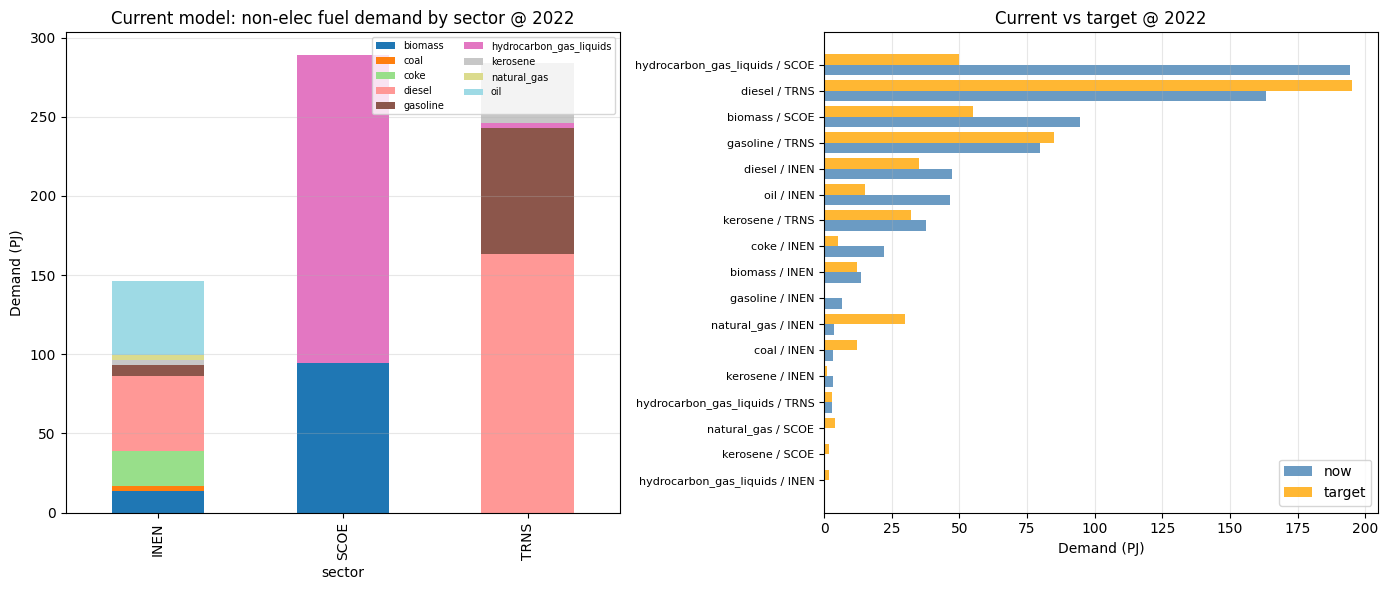

In [28]:
import matplotlib.pyplot as plt

# Build plot data: fuel x sector grid of (now, target, gap)
plot_data = []
for fuel in NON_ELEC_FUELS:
    if fuel not in fuel_table.index: continue
    for sec in ["INEN", "SCOE", "TRNS"]:
        now = float(fuel_table.loc[fuel, sec])
        tgt = NON_ELEC_TARGETS_PJ_2022.get((fuel, sec), 0.0)
        plot_data.append({"fuel": fuel, "sector": sec, "now": now, "target": tgt})
pd_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: stacked bar by sector showing fuel mix
ax = axes[0]
piv = pd_df.pivot(index="sector", columns="fuel", values="now")
piv.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("Demand (PJ)")
ax.set_title(f"Current model: non-elec fuel demand by sector @ {CALIB_YEAR}")
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3, axis="y")

# Right: bar of current vs target per (fuel, sector) cell
ax = axes[1]
pd_df["label"] = pd_df["fuel"] + " / " + pd_df["sector"]
mask = (pd_df["now"] > 0.5) | (pd_df["target"] > 0.5)
sub = pd_df[mask].sort_values("now", ascending=True)
y = np.arange(len(sub))
width = 0.4
ax.barh(y - width/2, sub["now"],    width, label="now", color="steelblue", alpha=0.8)
ax.barh(y + width/2, sub["target"], width, label="target", color="orange", alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(sub["label"], fontsize=8)
ax.set_xlabel("Demand (PJ)")
ax.set_title(f"Current vs target @ {CALIB_YEAR}")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()


## Notes

### How to apply corrections

The Stage A diagnostic identifies which `(sector, fuel)` cells deviate from reasonable Morocco 2022 values. To correct them:

1. **Identify the underlying SISEPUEDE subcategory** the deviation belongs to. The `(INEN_now, SCOE_now, TRNS_now)` aggregates hide which specific industry (cement, chemicals…) or which residential/commercial bucket is responsible. Use the underlying `frac_inen_energy_<industry>_<fuel>` / `frac_scoe_energy_<cat>_<fuel>` columns in the CSV.
2. **Decide the new fraction** for that subcategory × fuel. Each subcategory's fuel fractions must sum to 1.
3. **Fill `FRAC_OVERRIDES`** with `{(subcategory, fuel): new_fraction}` and re-run.
   The notebook handles renormalization of the other fuels for that subcategory.

### Likely culprits per row

- **LPG over-prediction in SCOE** → `frac_scoe_energy_residential_hydrocarbon_gas_liquids`   is too high. Lower it; raise biomass and electricity to compensate.
- **NG under-prediction in INEN** → `frac_inen_energy_chemicals_natural_gas` (OCP ammonia)   and `frac_inen_energy_cement_natural_gas` are too low. Raise them; lower coal/coke if needed.
- **Coke over-prediction in INEN** → `frac_inen_energy_metals_coke` likely too high   for Morocco's small steel industry.
- **Biomass over-prediction in SCOE** → traditional firewood may have been overstated;   lower `frac_scoe_energy_residential_biomass`.

### Sources for `NON_ELEC_TARGETS_PJ_2022`

- IEA Morocco country profile (https://www.iea.org/countries/morocco) - 2022 totals by fuel
- HCP Balance Énergétique Nationale du Maroc 2022 (national stats office)
- SNBC volume 2 / LT-LEDS 2024 - sectoral mix targets and historicals
- `calibration_log.md` NIR-verified entries (residential 7.9 MtCO2, commercial 0.76 MtCO2)
- LT-LEDS 2030 INEN mix (30% elec / 43% fossil / 27% RE) interpolated back to 2022

### What this notebook does NOT do

- It does not calibrate ENTC (power generation) fuel inputs. Those live in NemoMod inputs.
- It does not change `consumpinit_*` (which would shift total sector demand). Only fractions move.
- It does not enforce per-subcategory closure beyond renormalization to sum=1 within one subcategory.
